# This is Prevalence of COPD in Adults >= 18
COPD2_0: Prevalence of chronic obstructive pulmonary disease among adults >= 18
Prevalence shows Crude Rate in percentage 

## Data Preprocessing and Cleaning

In [83]:
# Imports
import pandas as pd

In [92]:
# Import COPD Data from CDI Datasset
csv_path = '/home/daniel.lien/dev/homework/data/cleaned_copd_data.csv'
df = pd.read_csv(csv_path)


In [93]:
# Filter COPD Data for Question 2 (COPD2_0): Prevalence of COPD in Adults >= 18
df = df[df['QuestionID'] == 'COPD2_0']

In [94]:
# Drop All Unecessary Columns
df = df.drop(columns=[
            'Topic',
            'Question',
            'GeoLocation',
            'QuestionID',
            'StratificationCategoryID1',
            'StratificationID1',
            'DataValueUnit',
            'StratificationCategory1'
])

In [95]:
# Remove Certain value in each Column
df = df[df['Stratification1'] != 'Overall'] #Remove rows with overall 
df = df[df['DataValueType'] == 'Crude Prevalence'] #only keep crude prevalence
df = df.dropna(subset=['DataValue']) #drop all na rows
df = df.drop(columns=['DataValueType']) #drop data value type since we know this is prevalence %


In [96]:
# Rename Columns to 
df.rename(columns={'YearStart': 'Year',
                    'LocationDesc': 'State',
                    'DataValue': 'Prevalence',
                    'Stratification1': 'Stratification'}, inplace=True)


In [97]:
#Sort by state and year
df.sort_values(['State', 'Year'], inplace=True)

In [98]:
print(df.shape)
df.head()

(2617, 4)


,Year,State,Prevalence,Stratification
83115,2011,Alabama,10.9,Female
83354,2011,Alabama,8.3,Male
83439,2011,Alabama,6.4,"Black, non-Hispanic"
83492,2011,Alabama,13.5,"Other, non-Hispanic"
83708,2011,Alabama,10.7,"White, non-Hispanic"


In [99]:
output_dir = '/home/daniel.lien/dev/homework/data/Single_Questions/COPD2_0.csv'
df.to_csv(output_dir, index=False)

## Exploratory Data Analysis

In [100]:
csv_path = '/home/daniel.lien/dev/homework/data/Single_Questions/COPD2_0.csv'
df = pd.read_csv(csv_path)
df.head()

,Year,State,Prevalence,Stratification
0,2011,Alabama,10.9,Female
1,2011,Alabama,8.3,Male
2,2011,Alabama,6.4,"Black, non-Hispanic"
3,2011,Alabama,13.5,"Other, non-Hispanic"
4,2011,Alabama,10.7,"White, non-Hispanic"


In [101]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


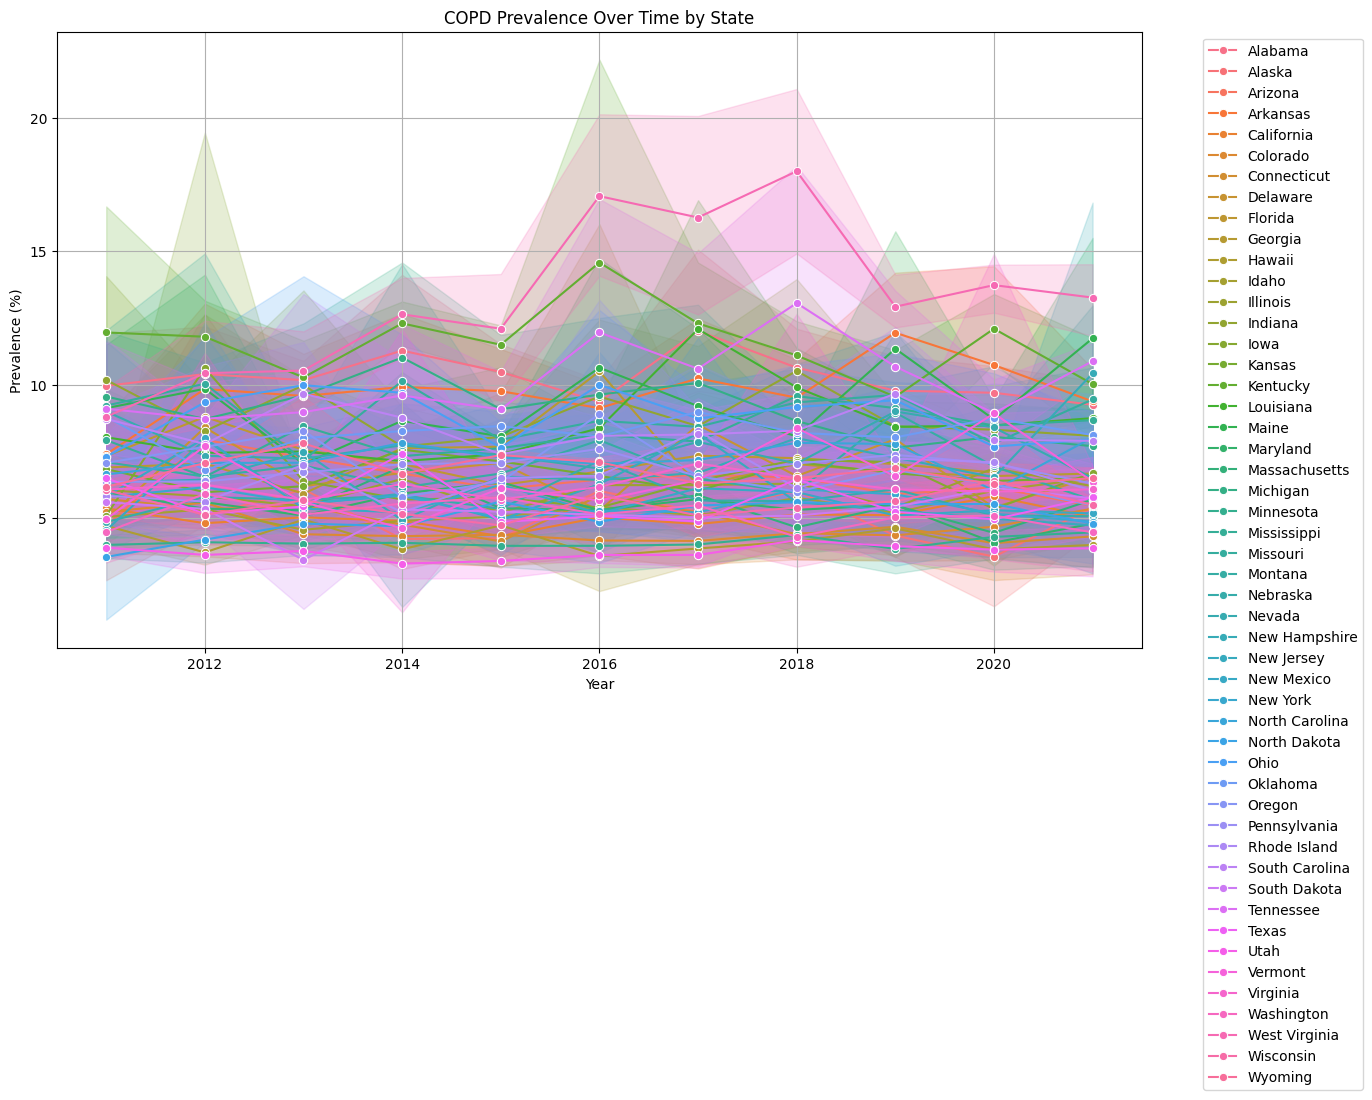

In [102]:
#COPD prevalence overtime by state
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='Year', y='Prevalence', hue='State', marker='o')
plt.title('COPD Prevalence Over Time by State')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

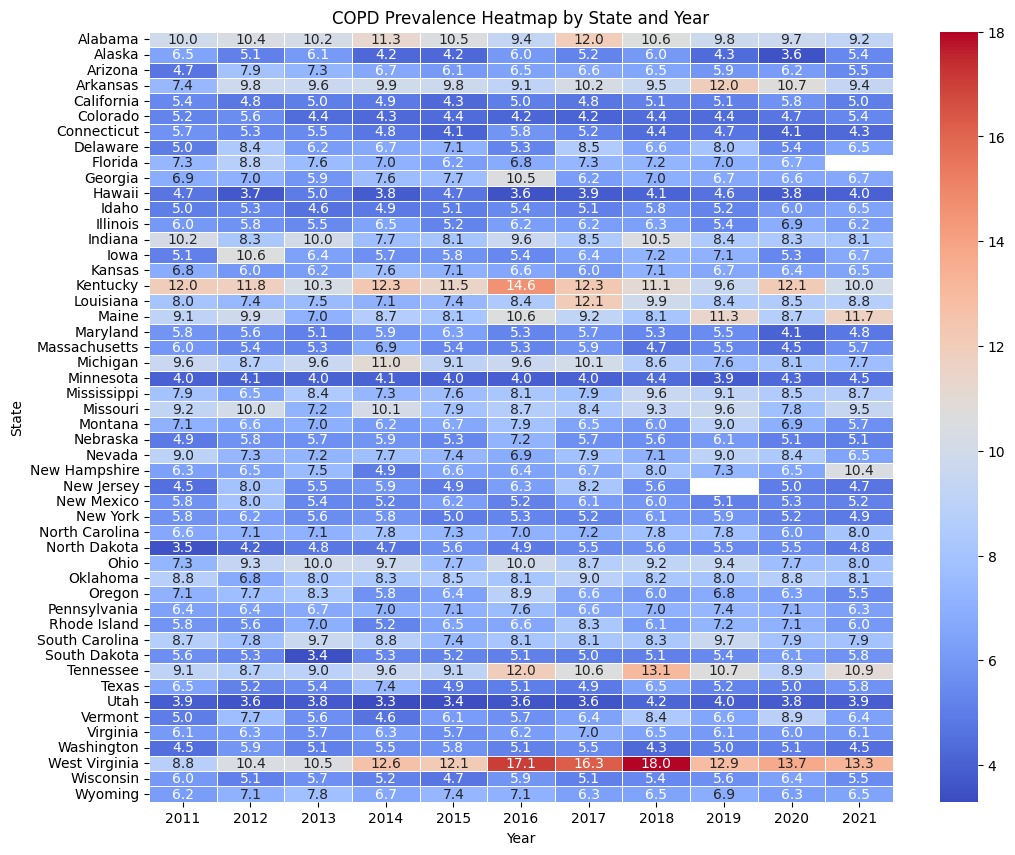

In [103]:
heatmap_data = df.pivot_table(values='Prevalence', index='State', columns='Year', aggfunc='mean')
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".1f", linewidths=0.5)
plt.title('COPD Prevalence Heatmap by State and Year')
plt.show()

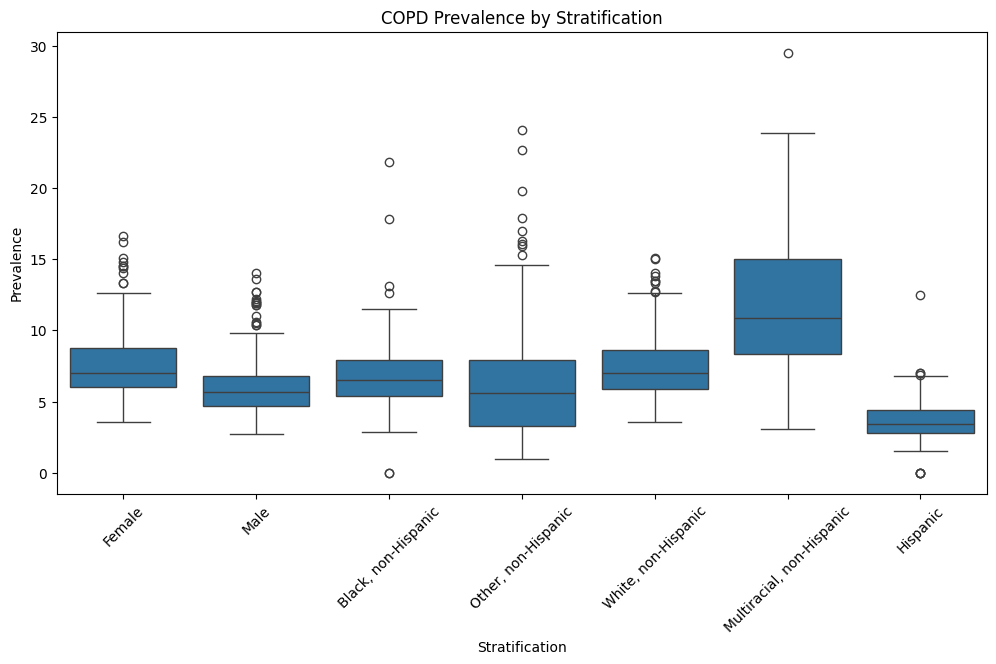

In [105]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Stratification', y='Prevalence')
plt.title('COPD Prevalence by Stratification')
plt.xticks(rotation=45)
plt.show()


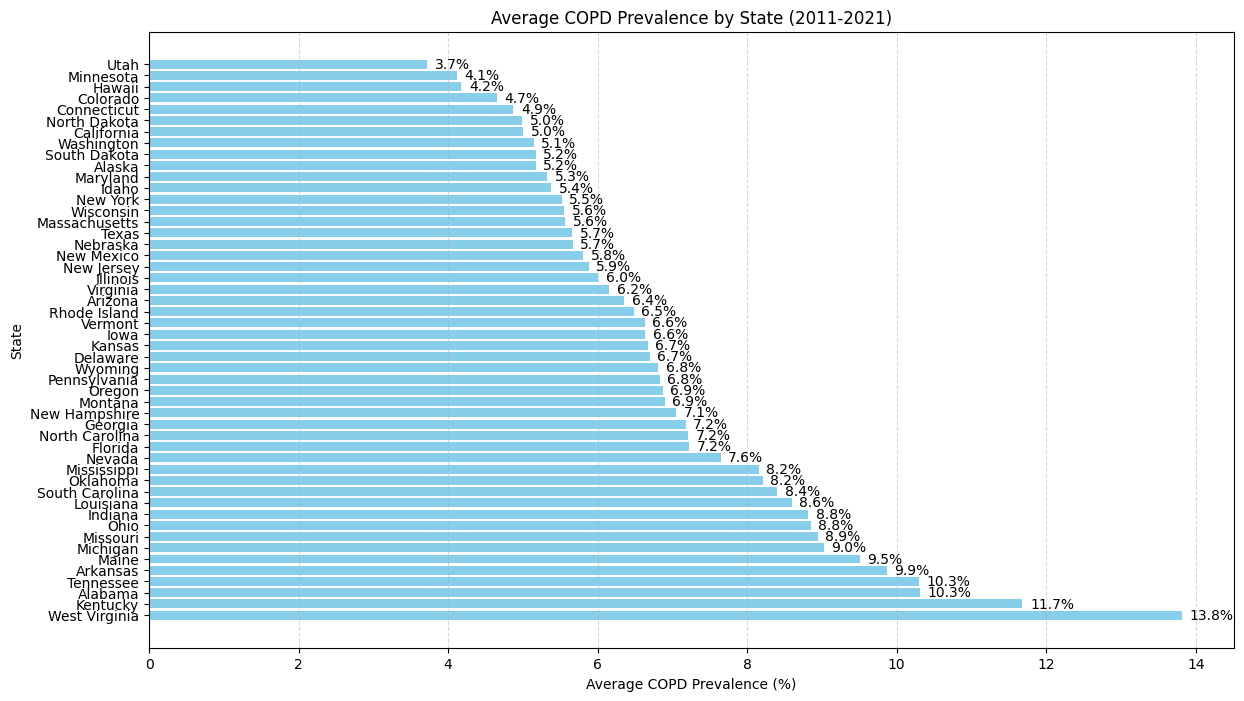

In [106]:
#Prevalence by state 
# Aggregate to get the average prevalence by state
avg_prevalence_by_state = df.groupby('State')['Prevalence'].mean().reset_index()

# Sort by prevalence for better visualization
avg_prevalence_by_state.sort_values('Prevalence', ascending=False, inplace=True)

# ---------------------
# 📊 Bar Chart
plt.figure(figsize=(14, 8))
plt.barh(avg_prevalence_by_state['State'], avg_prevalence_by_state['Prevalence'], color='skyblue')

# Labels and title
plt.xlabel('Average COPD Prevalence (%)')
plt.ylabel('State')
plt.title('Average COPD Prevalence by State (2011-2021)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the values on the bars
for index, value in enumerate(avg_prevalence_by_state['Prevalence']):
    plt.text(value + 0.1, index, f'{value:.1f}%', va='center')

plt.show()

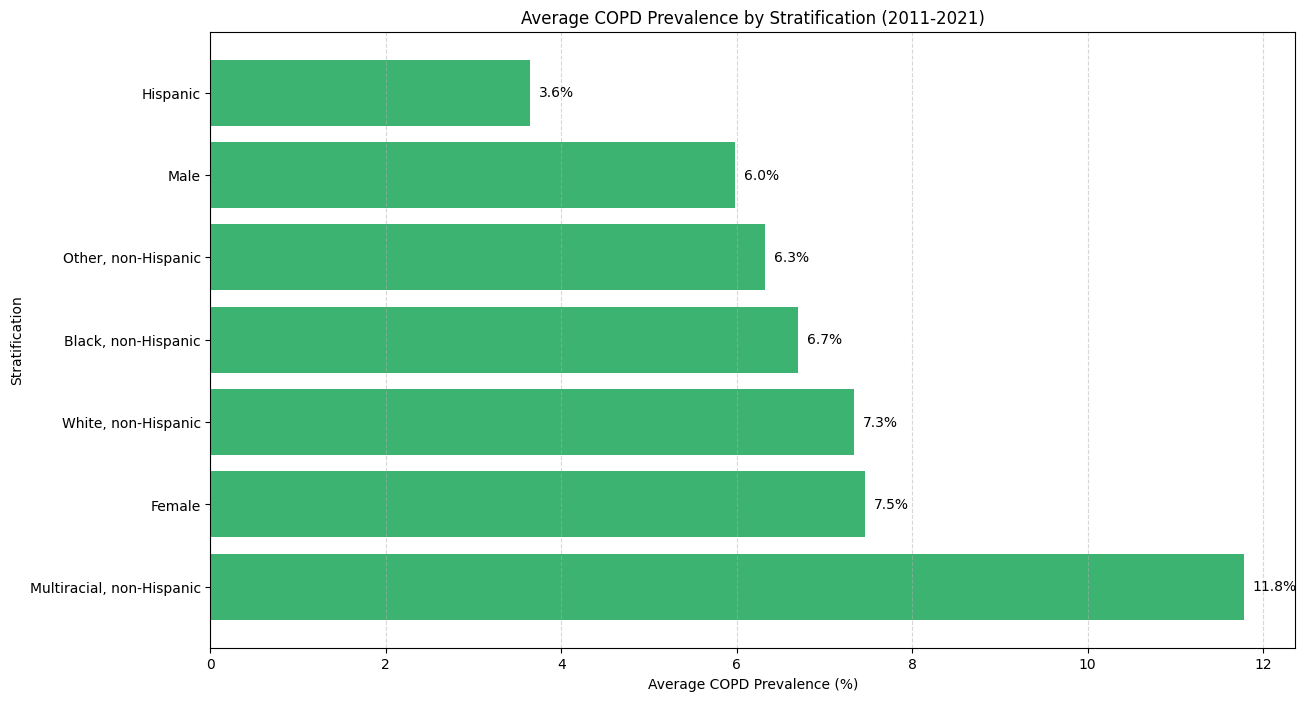

In [108]:
#Average Prelalence by Stratification
# Aggregate to get the average prevalence by stratification group
avg_prevalence_by_group = df.groupby('Stratification')['Prevalence'].mean().reset_index()

# Sort by prevalence for better visualization
avg_prevalence_by_group.sort_values('Prevalence', ascending=False, inplace=True)

# ---------------------
# 📊 Bar Chart
plt.figure(figsize=(14, 8))
plt.barh(avg_prevalence_by_group['Stratification'], avg_prevalence_by_group['Prevalence'], color='mediumseagreen')

# Labels and title
plt.xlabel('Average COPD Prevalence (%)')
plt.ylabel('Stratification')
plt.title('Average COPD Prevalence by Stratification (2011-2021)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the values on the bars
for index, value in enumerate(avg_prevalence_by_group['Prevalence']):
    plt.text(value + 0.1, index, f'{value:.1f}%', va='center')

In [110]:
# 🚦 Separate Gender and Race Groups
gender_groups = ['Male', 'Female']
gender_df = df[df['Stratification'].isin(gender_groups)]
race_df = df[~df['Stratification'].isin(gender_groups)]

# ---------------------
# 📊 Aggregate Prevalence
# Average prevalence by group
avg_gender = gender_df.groupby('Stratification')['Prevalence'].mean().reset_index()
avg_race = race_df.groupby('Stratification')['Prevalence'].mean().reset_index()

# Sort for better visualization
avg_gender.sort_values('Prevalence', ascending=False, inplace=True)
avg_race.sort_values('Prevalence', ascending=False, inplace=True)

# ---------------------


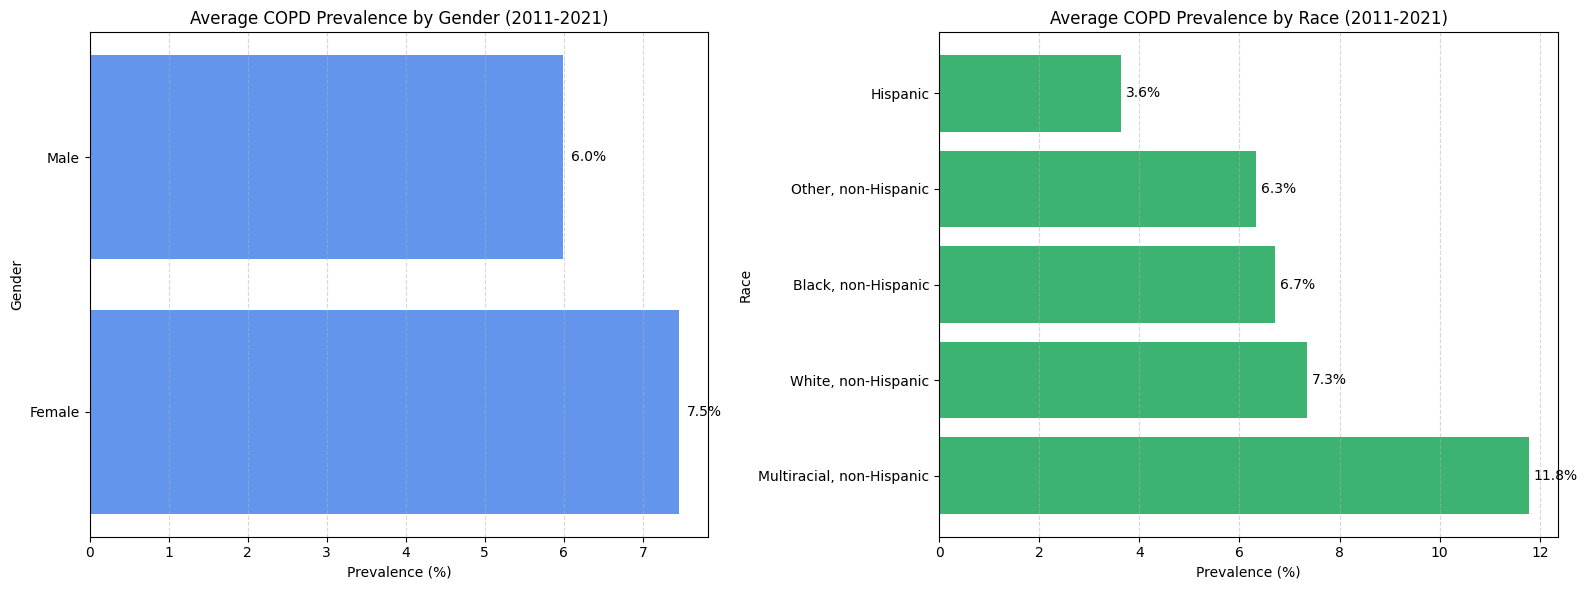

In [78]:
# ---------------------
# 📈 Plotting the Two Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gender Bar Chart
axes[0].barh(avg_gender['Group'], avg_gender['Prevalence'], color='cornflowerblue')
axes[0].set_title('Average COPD Prevalence by Gender (2011-2021)')
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_ylabel('Gender')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for index, value in enumerate(avg_gender['Prevalence']):
    axes[0].text(value + 0.1, index, f'{value:.1f}%', va='center')

# Race Bar Chart
axes[1].barh(avg_race['Group'], avg_race['Prevalence'], color='mediumseagreen')
axes[1].set_title('Average COPD Prevalence by Race (2011-2021)')
axes[1].set_xlabel('Prevalence (%)')
axes[1].set_ylabel('Race')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for index, value in enumerate(avg_race['Prevalence']):
    axes[1].text(value + 0.1, index, f'{value:.1f}%', va='center')

plt.tight_layout()
plt.show()

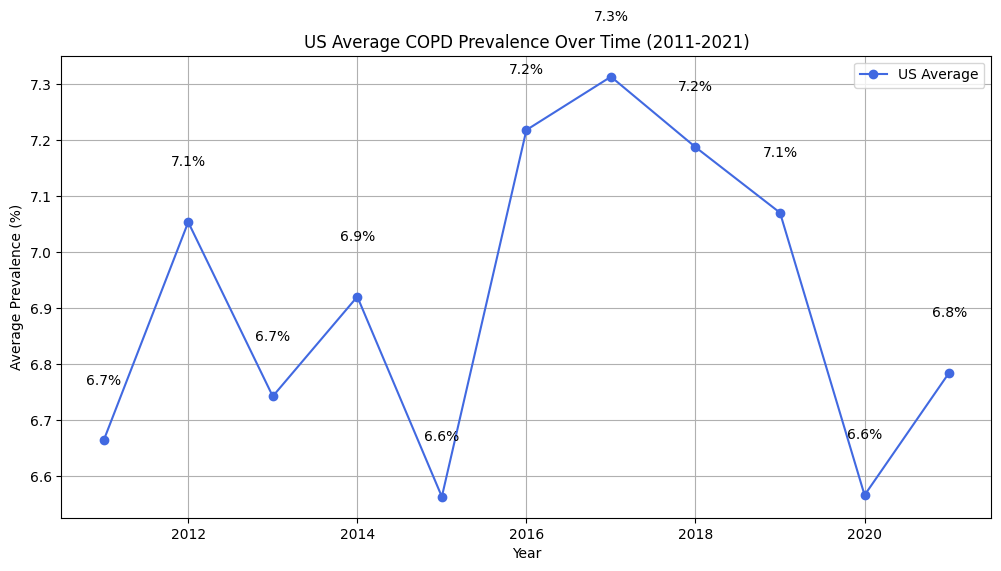

In [111]:
#Average us COPD prevalence over the past year
# ---------------------
# 🚦 Calculate US Average Prevalence by Year
us_avg_prevalence = df.groupby('Year')['Prevalence'].mean().reset_index()

# ---------------------
# 📈 Plotting the US Average Prevalence Over the Years
plt.figure(figsize=(12, 6))
plt.plot(us_avg_prevalence['Year'], us_avg_prevalence['Prevalence'], marker='o', linestyle='-', color='royalblue', label='US Average')

# Labels and Title
plt.title('US Average COPD Prevalence Over Time (2011-2021)')
plt.xlabel('Year')
plt.ylabel('Average Prevalence (%)')
plt.grid(True)

# Add data labels
for year, prevalence in zip(us_avg_prevalence['Year'], us_avg_prevalence['Prevalence']):
    plt.text(year, prevalence + 0.1, f'{prevalence:.1f}%', ha='center')

plt.legend()
plt.show()

In [112]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

/home/daniel.lien/dev/homework/Chronic_Disease_Indicators_Data_Visualization/.venv/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/daniel.lien/dev/homework/Chronic_Disease_Indicators_Data_Visualization/.venv/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/daniel.lien/dev/homework/Chronic_Disease_Indicators_Data_Visualization/.venv/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


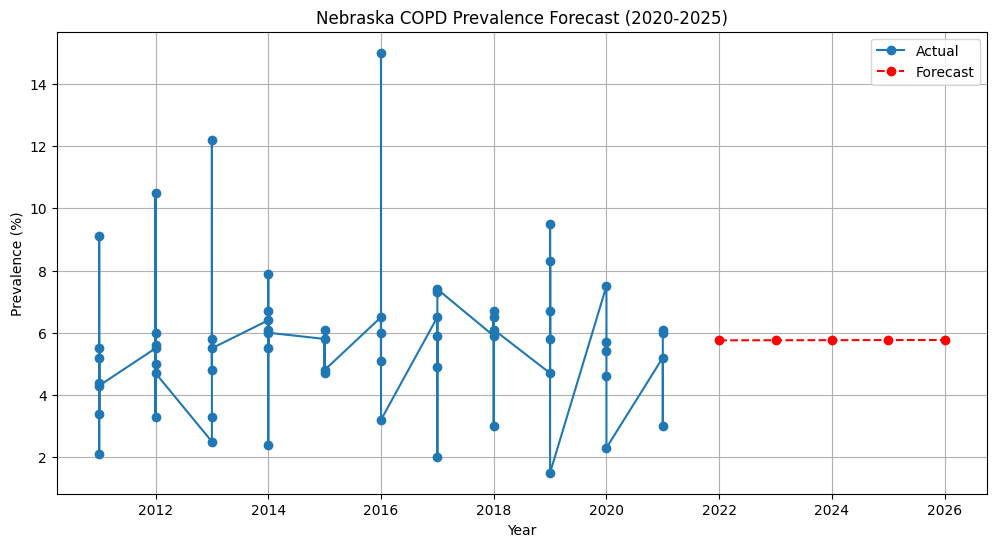

In [113]:
nebraska_df = df[df['State'] == 'Nebraska'].sort_values('Year')
model = ExponentialSmoothing(nebraska_df['Prevalence'], trend='add', seasonal=None, seasonal_periods=None)
fit = model.fit()

# Forecast for 2020-2025
future_years = pd.date_range(start='2022', periods=5, freq='Y').year
forecast = fit.forecast(steps=5)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(nebraska_df['Year'], nebraska_df['Prevalence'], label='Actual', marker='o')
plt.plot(future_years, forecast, label='Forecast', marker='o', linestyle='--', color='red')
plt.title('Nebraska COPD Prevalence Forecast (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

## Model Forecasting / Predictions


Since our target variable is numerical (%), we are dealing with a regression problem. 
Therefore we have to use regression models and metrics

1) Linear Regresssion (baseline model)
- Good for detecting linear trends in the data
- serves as a baseline to compare against more complex models
Cons: assumes a linear relationship between year and prevalence, which may not hold true
2) Polynomial regression
- Extension of Linear regression that fits the data to a polynomail curve
- captures non-linear trends
- useful when prevalence rate shows accelerating or decelerating trends over time
3) Random forest regression
- An ensemble method that uses multiplel decision trees and averages the result for better accuracy
- Good for complex non-linear relationships , and moderate sized time series data
- Requires lots of data to avoid overfitting
4) XGBoost
- Gradient boosting model that combines weak learners to create a stronger predictive model
- good for medium to large datasets, good at handling non-linear
- pros: accurate, robust to outliers
- cons: computationally expensive, requires hyperparameter tuning to avoid overfitting
5) Arima
- traditional time series model that combines auto regression and moving average
- good for time series forecasting
cons: assuems stationarity (constant mean and variance,) which may not hold
    requires parameter tuning for AR, MA, differencing

Metrics:
1) Mean Absolute Error (MAE)
Explains the average magnitude of the errors
2) Mean Squared Errors (MSE)
Similar to MAE, but sqyuares the errors, which penalizes them more
3) Root Mean Squared Error (RSME)
Keep same unit as target variable, making it easy to interpret
4) r2 (Coefficient of Determination)
Measures hwo well the model explains the variance in the data
Values closer to 1 indicate good fit, while 0 means poor fit



Note:
For time series forecasting, using a purely random split violates the temporal order of the data, which can lead to data leakage.

Why?
You could have future years in the training set and earlier years in the test set, which doesn't simulate real-world forecasting.
For example:

    Training set: 2011, 2013, 2018, 2021  
    Test set: 2012, 2014, 2019  
    This would make the model see future values (2021) while training and then predict past values (2014), which is unrealistic for forecasting.
Temporal leakage: Future values could end up in the training set, making the model overly optimistic.

Since your dataset spans 2011-2021 across multiple states, you should:

Split by year rather than randomly.
Ensure that the train set contains earlier years and the test set contains later years.

#Check with Rolling Cross-Validation
If you want to enhance the evaluation, you can use rolling cross-validation instead of a single train-test split.
